# Neural Network from Scratch for MNIST (Multi-class Classification)

In this notebook, we will implement a **Neural Network with one hidden layer** from scratch. We'll cover the mathematical foundations, step-by-step code implementation, and evaluation of the model for **multi-class classification** using the famous **MNIST dataset**.

The goal is to provide a clear understanding of how a multi-layer neural network works, how its learning rule (gradient descent with backpropagation) updates model parameters, and how to build a classification model without relying on high-level machine learning libraries.

<img src="https://raw.githubusercontent.com/AshishJangra27/In-One-Go/refs/heads/main/resourcess/simple_nn_for_mnist.png" alt="Artificial Neuron Banner" width="1000"/>

### Table of Contents

1.  **Importing Libraries**
2.  **Loading and Exploring the MNIST Dataset**
3.  **Preparing the Data**
4.  **Initializing Parameters (Weights and Biases)**
5.  **Defining Activation Functions**
6.  **Forward Propagation**
7.  **Loss Function**
8.  **Backward Propagation**
9.  **Updating Parameters**
10. **Training the Model**
11. **Evaluating Model Performance with Test Data**
12. **Visualizing Model Performance**
13. **Comparison with Scikit-learn MLPClassifier (Optional)**
14. **Conclusion**

## 1. Importing Libraries

We will import the necessary Python libraries for numerical operations, data manipulation, dataset loading, and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist # For MNIST dataset
from tensorflow.keras.utils import to_categorical # For one-hot encoding labels
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading and Exploring the MNIST Dataset

We will use the **MNIST dataset**, a large database of handwritten digits, for our multi-class classification task. Each image is 28x28 pixels, and there are 10 classes (digits 0-9).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of full training features (X_train_full): (60000, 28, 28)
Shape of full training labels (y_train_full): (60000,)
Shape of full test features (X_test_full): (10000, 28, 28)
Shape of full test labels (y_test_full): (10000,)


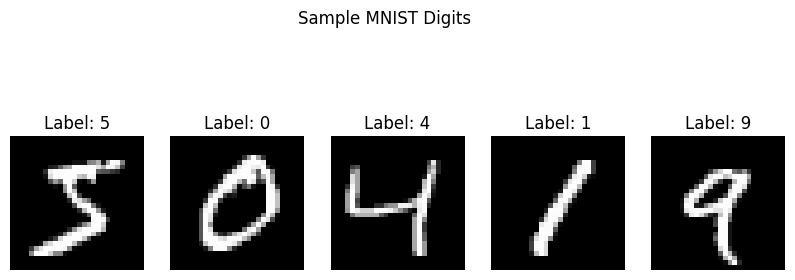

MNIST dataset loaded and samples displayed successfully.


In [2]:
# Load the MNIST dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

print(f"Shape of full training features (X_train_full): {X_train_full.shape}")
print(f"Shape of full training labels (y_train_full): {y_train_full.shape}")
print(f"Shape of full test features (X_test_full): {X_test_full.shape}")
print(f"Shape of full test labels (y_test_full): {y_test_full.shape}")

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(f"Label: {y_train_full[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

print("MNIST dataset loaded and samples displayed successfully.")

## 3. Preparing the Data

To ensure our model performs optimally, we will preprocess the data by:
1.  **Reshaping the images**: Flattening the 28x28 images into 784-dimensional vectors.
2.  **Normalizing pixel values**: Scaling pixel intensities from 0-255 to 0-1.
3.  **One-hot encoding labels**: Converting integer labels (0-9) into a binary vector format (e.g., 3 becomes `[0,0,0,1,0,0,0,0,0,0]`).
4.  **Splitting the dataset**: (Already done by `mnist.load_data` into train/test sets, so we'll just use them directly).

In [3]:
# Flatten the images: 28x28 to 784
X_train = X_train_full.reshape(X_train_full.shape[0], -1)
X_test = X_test_full.reshape(X_test_full.shape[0], -1)

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train_full, num_classes=10)
y_test = to_categorical(y_test_full, num_classes=10)

print("Data prepared successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data prepared successfully.
X_train shape: (60000, 784)
y_train shape: (60000, 10)
X_test shape: (10000, 784)
y_test shape: (10000, 10)


## 4. Initializing Parameters (Weights and Biases)

For a neural network with a single hidden layer, we need to initialize weights and biases for two layers: input-to-hidden1 and hidden1-to-output. Random initialization with small values is crucial, and biases are often initialized to zeros.

Let's define:
*   `n_x`: number of input features (784 for MNIST 28x28 flattened)
*   `n_h1`: number of neurons in the hidden layer (50)
*   `n_y`: number of neurons in the output layer (10 for MNIST digits)

Weights will be matrices, and biases will be vectors:
*   `W1`: weights for input to hidden1 (shape `(n_h1, n_x)`)
*   `b1`: biases for hidden1 (shape `(n_h1, 1)`)
*   `W2`: weights for hidden1 to output (shape `(n_y, n_h1)`)
*   `b2`: biases for output (shape `(n_y, 1)`)

In [4]:
np.random.seed(42) # for reproducibility

n_x = X_train.shape[1]  # Number of input features (784)
n_h1 = 50               # Number of neurons in the first (and only) hidden layer
n_y = y_train.shape[1]  # Number of neurons in the output layer (10 for one-hot encoded labels)

# Initialize weights with He initialization (for ReLU) or small random values
# Using a small random scale here, often glorot/he initialization is better for deep nets
W1 = np.random.randn(n_h1, n_x) * 0.01
b1 = np.zeros((n_h1, 1))

W2 = np.random.randn(n_y, n_h1) * 0.01 # W2 now connects hidden1 to output
b2 = np.zeros((n_y, 1))                # b2 now biases output

parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

print(f"Initial W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"Initial W2 shape: {W2.shape}, b2 shape: {b2.shape}")
print("Parameters initialized successfully for 1 hidden layer model.")

Initial W1 shape: (50, 784), b1 shape: (50, 1)
Initial W2 shape: (10, 50), b2 shape: (10, 1)
Parameters initialized successfully for 1 hidden layer model.


## 5. Defining Activation Functions

For a neural network with hidden layers, we typically use different activation functions for the hidden layers and the output layer.

### ReLU for Hidden Layers
**ReLU (Rectified Linear Unit)** is commonly used in hidden layers:

$$ \text{ReLU}(z) = \max(0, z) $$

- Outputs 0 if input is negative, otherwise returns the input
- Helps in learning complex patterns efficiently

### Softmax for Output Layer
**Softmax** is used in multi-class classification to output a probability distribution over multiple classes:

$$ \sigma(\mathbf{z})_j = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}} $$

- Converts a vector of arbitrary real values into a vector of probabilities.
- Sum of probabilities across all classes is 1.
- Suitable for output layer in multi-class classification.

### Why Activation Functions are Needed
- Introduce non-linearity
- Without them, the model behaves like a linear model
- Enable learning of complex relationships

In [5]:
def relu(z):
    """Applies the ReLU activation function."""
    return np.maximum(0, z)

def softmax(z):
    """Applies the Softmax activation function."""
    # Subtract max for numerical stability
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def relu_backward(dA, Z):
    """Backward pass for ReLU activation."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

# For softmax with categorical cross-entropy, the backward pass simplifies greatly:
# dZ (dL/dZ) for softmax + cross-entropy is simply (A - Y)
# So, we don't need a separate softmax_backward function here, it's integrated into backprop.

print("ReLU and Softmax activation functions and ReLU backward pass defined successfully.")

ReLU and Softmax activation functions and ReLU backward pass defined successfully.


## 6. Forward Propagation

Forward propagation is the process of passing input data through the neural network to obtain an output. For our single-hidden-layer neural network, the steps are:

### Step 1: Linear Combination (Hidden Layer 1)
$$ Z^{[1]} = W^{[1]}X + b^{[1]} $$

### Step 2: Activation (Hidden Layer 1)
$$ A^{[1]} = \text{ReLU}(Z^{[1]}) $$

### Step 3: Linear Combination (Output Layer)
$$ Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]} $$

### Step 4: Activation (Output Layer)
$$ A^{[2]} = \text{softmax}(Z^{[2]}) $$

- $A^{[2]}$ represents the predicted probability distribution over the classes.

In [6]:
def forward_propagation(X, parameters):
    """Implements the forward propagation for a single-hidden-layer neural network."""
    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], \
                                     parameters['W2'], parameters['b2']

    # Input layer to Hidden Layer 1
    Z1 = np.dot(W1, X.T) + b1
    A1 = relu(Z1)

    # Hidden Layer 1 to Output Layer
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

print("Forward propagation function defined successfully for 1 hidden layer model.")

Forward propagation function defined successfully for 1 hidden layer model.


## 7. Loss Function

For multi-class classification with a Softmax output, the **Categorical Cross-Entropy Loss** is commonly used. It measures the performance of a classification model whose output is a probability distribution over multiple classes.

### Loss for a Single Training Example

For one training example $(x^{(i)}, y^{(i)})$, where $y^{(i)}$ is a one-hot encoded vector:

$$ \mathcal{L}(y^{(i)}, \hat{y}^{(i)}) = -\sum_{j=0}^{K-1} y_j^{(i)} \log(\hat{y}_j^{(i)}) $$

### Cost Function over All Examples

For $m$ training examples, the overall cost is the average loss:

$$ J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{j=0}^{K-1} y_j^{(i)} \log(\hat{y}_j^{(i)}) $$

### Key Properties

- Works with probability outputs (from Softmax)
- Penalizes wrong confident predictions heavily
- Continuous and differentiable
- Suitable for gradient descent optimization

In [7]:
def compute_loss(A4, Y):
    """Computes the categorical cross-entropy loss."""
    m = Y.shape[0]
    # Y is typically (m, num_classes) - transpose to (num_classes, m) for dot product with A4
    # A4 is (num_classes, m)
    Y_reshaped = Y.T

    # Compute cross-entropy loss
    # Add a small epsilon to prevent log(0) issues
    epsilon = 1e-10
    cost = - (1 / m) * np.sum(Y_reshaped * np.log(A4 + epsilon))

    # Squeeze cost to ensure it's a scalar
    cost = np.squeeze(cost)
    return cost

print("Loss function defined successfully.")

Loss function defined successfully.


## 8. Backward Propagation

Backward propagation (backprop) is used to compute the gradients of the loss function with respect to the network parameters ($W^{[l]}, b^{[l]}$ for $l=1, 2$).

### Step 1: Derivative of Loss w.r.t. $Z^{[2]}$ (Output Layer)
For Softmax activation with Categorical Cross-Entropy loss, the derivative of the loss with respect to $Z^{[2]}$ simplifies significantly:
$$ dZ^{[2]} = A^{[2]} - Y $$

### Step 2: Gradients for Output Layer Parameters
$$ dW^{[2]} = \frac{1}{m} dZ^{[2]} (A^{[1]})^T $$
$$ db^{[2]} = \frac{1}{m} \sum dZ^{[2]} $$

### Step 3: Derivative of Loss w.r.t. $A^{[1]}$
$$ dA^{[1]} = (W^{[2]})^T dZ^{[2]} $$

### Step 4: Derivative of Loss w.r.t. $Z^{[1]}$ (Hidden Layer 1)
$$ dZ^{[1]} = dA^{[1]} \odot \text{ReLU}'(Z^{[1]}) $$

### Step 5: Gradients for Hidden Layer 1 Parameters
$$ dW^{[1]} = \frac{1}{m} dZ^{[1]} (X)^T $$
$$ db^{[1]} = \frac{1}{m} \sum dZ^{[1]} $$

In [8]:
def backward_propagation(parameters, cache, X, Y):
    """Implements the backward propagation for a single-hidden-layer neural network."""
    m = X.shape[0]
    Y_reshaped = Y.T # Reshape Y to (num_classes, m)
    X_reshaped = X.T # Reshape X to (n_x, m)

    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], \
                                     parameters['W2'], parameters['b2']
    A1, Z1, A2, Z2 = cache['A1'], cache['Z1'], \
                                     cache['A2'], cache['Z2']

    grads = {}

    # Output Layer (Softmax + Categorical Cross-Entropy)
    dZ2 = A2 - Y_reshaped # Simplified derivative
    grads['dW2'] = (1 / m) * np.dot(dZ2, A1.T)
    grads['db2'] = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden Layer 1
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = relu_backward(dA1, Z1)
    grads['dW1'] = (1 / m) * np.dot(dZ1, X_reshaped.T)
    grads['db1'] = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return grads

print("Backward propagation function defined successfully for 1 hidden layer model.")

Backward propagation function defined successfully for 1 hidden layer model.


## 9. Updating Parameters

Once the gradients are computed using backward propagation, we update the network parameters (weights and biases) using **gradient descent**.

### Update Rule

For any parameter (for example, $W^{[l]}$):

$$ W^{[l]} = W^{[l]} - \alpha \frac{\partial J}{\partial W^{[l]}} $$

### General Form for All Parameters

$$ W^{[l]} = W^{[l]} - \alpha \, dW^{[l]} $$

$$ b^{[l]} = b^{[l]} - \alpha \, db^{[l]} $$

### Key Points

- $\alpha$ is the **learning rate**
- Controls how big each update step is
- Too large → may overshoot minimum
- Too small → slow convergence

### Intuition

- Gradients point in the direction of increasing loss
- We move in the opposite direction to minimize the loss

In [11]:
def update_parameters(parameters, grads, learning_rate):
    """Updates parameters using gradient descent."""
    parameters['W1'] = parameters['W1'] - learning_rate * grads['dW1']
    parameters['b1'] = parameters['b1'] - learning_rate * grads['db1']
    parameters['W2'] = parameters['W2'] - learning_rate * grads['dW2']
    parameters['b2'] = parameters['b2'] - learning_rate * grads['db2']
    return parameters

print("Parameter update function defined successfully.")

# Re-initialize parameters before training to reflect the new 1-hidden-layer architecture
np.random.seed(42)
n_x = X_train.shape[1]
n_h1 = 50  # Single hidden layer with 50 neurons
n_y = y_train.shape[1]

parameters = {
    "W1": np.random.randn(n_h1, n_x) * 0.01,
    "b1": np.zeros((n_h1, 1)),
    "W2": np.random.randn(n_y, n_h1) * 0.01,
    "b2": np.zeros((n_y, 1))
}

learning_rate = 0.01 # Increased learning rate
epochs = 1000       # Increased epochs

cost_history = []
accuracy_history = [] # To track accuracy during training
recorded_epochs = []  # To store epoch numbers when cost/accuracy are recorded
test_accuracy_history = [] # To track test accuracy during training

print(f"\nStarting training with learning rate = {learning_rate} and epochs = {epochs} (1 hidden layer, 50 neurons)")

for epoch in range(epochs):
    # Forward propagation (training data)
    A2, cache = forward_propagation(X_train, parameters)

    # Compute loss
    cost = compute_loss(A2, y_train)

    # Backward propagation
    grads = backward_propagation(parameters, cache, X_train, y_train)

    # Update parameters
    parameters = update_parameters(parameters, grads, learning_rate)

    # Calculate training accuracy
    predictions = np.argmax(A2, axis=0)
    true_labels = np.argmax(y_train, axis=1)
    accuracy = np.mean(predictions == true_labels)

    # Calculate test accuracy
    A2_test, _ = forward_propagation(X_test, parameters)
    predictions_test = np.argmax(A2_test, axis=0)
    true_labels_test = np.argmax(y_test, axis=1)
    test_accuracy = np.mean(predictions_test == true_labels_test)

    # Only append and print if it's a multiple of 5, or the first/last epoch
    if epoch % 5 == 0 or epoch == epochs - 1 or epoch == 0:
        recorded_epochs.append(epoch)
        cost_history.append(cost)
        accuracy_history.append(accuracy)
        test_accuracy_history.append(test_accuracy)
        print(f"Epoch {epoch}/{epochs}, Cost: {cost:.4f}, Train Accuracy: {accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

print("\nTraining complete.")
print(f"Final W1 shape: {parameters['W1'].shape}, b1 shape: {parameters['b1'].shape}")
print(f"Final W2 shape: {parameters['W2'].shape}, b2 shape: {parameters['b2'].shape}")

Parameter update function defined successfully.

Starting training with learning rate = 0.01 and epochs = 1000 (1 hidden layer, 50 neurons)
Epoch 0/1000, Cost: 2.3021, Train Accuracy: 0.1202, Test Accuracy: 0.1180
Epoch 5/1000, Cost: 2.3019, Train Accuracy: 0.1293, Test Accuracy: 0.1261
Epoch 10/1000, Cost: 2.3017, Train Accuracy: 0.1374, Test Accuracy: 0.1356
Epoch 15/1000, Cost: 2.3015, Train Accuracy: 0.1456, Test Accuracy: 0.1446
Epoch 20/1000, Cost: 2.3013, Train Accuracy: 0.1552, Test Accuracy: 0.1578
Epoch 25/1000, Cost: 2.3011, Train Accuracy: 0.1643, Test Accuracy: 0.1676
Epoch 30/1000, Cost: 2.3009, Train Accuracy: 0.1724, Test Accuracy: 0.1745
Epoch 35/1000, Cost: 2.3007, Train Accuracy: 0.1790, Test Accuracy: 0.1818
Epoch 40/1000, Cost: 2.3004, Train Accuracy: 0.1823, Test Accuracy: 0.1849
Epoch 45/1000, Cost: 2.3002, Train Accuracy: 0.1833, Test Accuracy: 0.1867
Epoch 50/1000, Cost: 2.3000, Train Accuracy: 0.1832, Test Accuracy: 0.1875
Epoch 55/1000, Cost: 2.2998, Train Ac

In [12]:
for epoch in range(epochs):
    # Forward propagation (training data)
    A2, cache = forward_propagation(X_train, parameters)

    # Compute loss
    cost = compute_loss(A2, y_train)

    # Backward propagation
    grads = backward_propagation(parameters, cache, X_train, y_train)

    # Update parameters
    parameters = update_parameters(parameters, grads, learning_rate)

    # Calculate training accuracy
    predictions = np.argmax(A2, axis=0)
    true_labels = np.argmax(y_train, axis=1)
    accuracy = np.mean(predictions == true_labels)

    # Calculate test accuracy
    A2_test, _ = forward_propagation(X_test, parameters)
    predictions_test = np.argmax(A2_test, axis=0)
    true_labels_test = np.argmax(y_test, axis=1)
    test_accuracy = np.mean(predictions_test == true_labels_test)

    # Only append and print if it's a multiple of 5, or the first/last epoch
    if epoch % 5 == 0 or epoch == epochs - 1 or epoch == 0:
        recorded_epochs.append(epoch)
        cost_history.append(cost)
        accuracy_history.append(accuracy)
        test_accuracy_history.append(test_accuracy)
        print(f"Epoch {epoch+1000}/{epochs+1000}, Cost: {cost:.4f}, Train Accuracy: {accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

print("\nTraining complete.")
print(f"Final W1 shape: {parameters['W1'].shape}, b1 shape: {parameters['b1'].shape}")
print(f"Final W2 shape: {parameters['W2'].shape}, b2 shape: {parameters['b2'].shape}")

Epoch 1000/2000, Cost: 1.0994, Train Accuracy: 0.7317, Test Accuracy: 0.7368
Epoch 1005/2000, Cost: 1.0922, Train Accuracy: 0.7336, Test Accuracy: 0.7393
Epoch 1010/2000, Cost: 1.0852, Train Accuracy: 0.7352, Test Accuracy: 0.7412
Epoch 1015/2000, Cost: 1.0783, Train Accuracy: 0.7370, Test Accuracy: 0.7430
Epoch 1020/2000, Cost: 1.0714, Train Accuracy: 0.7392, Test Accuracy: 0.7455
Epoch 1025/2000, Cost: 1.0647, Train Accuracy: 0.7411, Test Accuracy: 0.7475
Epoch 1030/2000, Cost: 1.0580, Train Accuracy: 0.7425, Test Accuracy: 0.7490
Epoch 1035/2000, Cost: 1.0515, Train Accuracy: 0.7441, Test Accuracy: 0.7506
Epoch 1040/2000, Cost: 1.0450, Train Accuracy: 0.7458, Test Accuracy: 0.7519
Epoch 1045/2000, Cost: 1.0386, Train Accuracy: 0.7472, Test Accuracy: 0.7539
Epoch 1050/2000, Cost: 1.0323, Train Accuracy: 0.7490, Test Accuracy: 0.7553
Epoch 1055/2000, Cost: 1.0261, Train Accuracy: 0.7505, Test Accuracy: 0.7575
Epoch 1060/2000, Cost: 1.0200, Train Accuracy: 0.7518, Test Accuracy: 0.7589

## 10. Training the Model

The training process involves iterating over the dataset for a specified number of epochs. In each epoch, we perform the following steps:

1.  **Forward Propagation**: Calculate the output of the network given the current parameters.
2.  **Compute Loss**: Evaluate the model's performance using the categorical cross-entropy loss function.
3.  **Backward Propagation**: Compute the gradients of the loss with respect to each parameter.
4.  **Update Parameters**: Adjust the parameters using gradient descent to minimize the loss.

We will also store the loss and training accuracy at intervals to monitor the training progress.

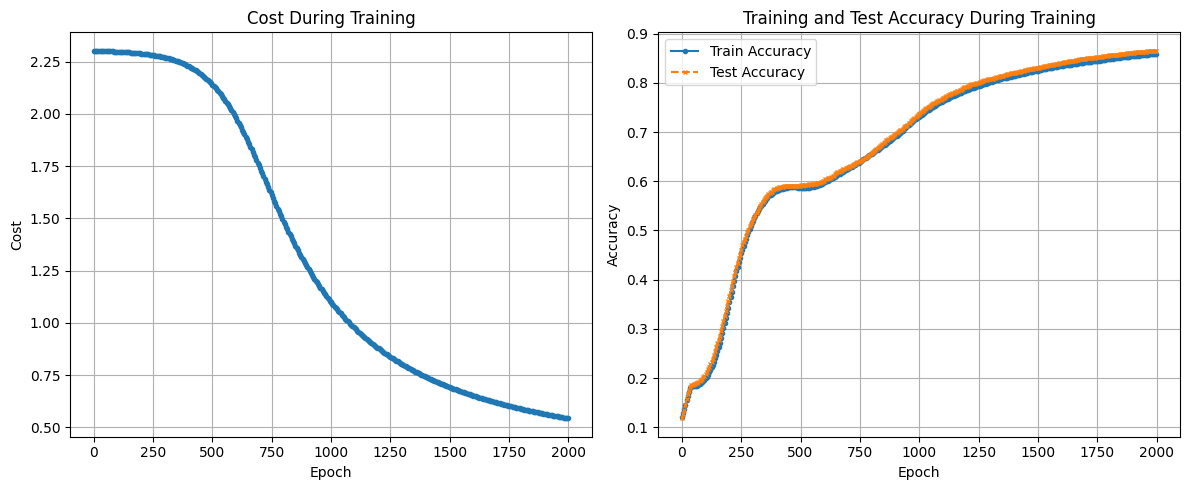

Cost and training accuracy plots generated successfully.


In [23]:
# recorded_epochs = np.array(recorded_epochs)
# recorded_epochs[201:] = recorded_epochs[201:] + 1000
# recorded_epochs = list(recorded_epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recorded_epochs, cost_history, marker='o', markersize=3, linestyle='-')
plt.title('Cost During Training')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recorded_epochs, accuracy_history, marker='o', markersize=3, linestyle='-', label='Train Accuracy')
plt.plot(recorded_epochs, test_accuracy_history, marker='x', markersize=3, linestyle='--', label='Test Accuracy')
plt.title('Training and Test Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Cost and training accuracy plots generated successfully.")

## 11. Evaluating Model Performance with Test Data

To evaluate the trained neural network model's performance on unseen test data, we will use common classification metrics:

*   **Accuracy**: The proportion of correctly classified instances among the total number of instances.
*   **Classification Report**: Provides precision, recall, f1-score, and support for each class.

For multi-class classification, `accuracy_score` and `classification_report` are appropriate.

In [24]:
def predict_nn(X, parameters):
    """Predicts multi-class labels for the neural network."""
    # Forward propagation to get probabilities
    A4, _ = forward_propagation(X, parameters)
    # Convert probabilities to class predictions (index of max probability)
    predictions = np.argmax(A4, axis=0)
    return predictions

# Make predictions on the test set
y_pred_test = predict_nn(X_test, parameters)
y_true_test = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to integers

# Calculate metrics
accuracy = accuracy_score(y_true_test, y_pred_test)

print("Model performance on test set:")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test))

Model performance on test set:
Accuracy: 0.8654

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       980
           1       0.93      0.97      0.95      1135
           2       0.88      0.83      0.86      1032
           3       0.84      0.87      0.86      1010
           4       0.83      0.86      0.85       982
           5       0.83      0.72      0.77       892
           6       0.89      0.91      0.90       958
           7       0.90      0.88      0.89      1028
           8       0.81      0.81      0.81       974
           9       0.80      0.80      0.80      1009

    accuracy                           0.87     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.87      0.86     10000



## 12. Visualizing Model Performance

To visually assess how well our neural network model performs, especially across different classes, we can generate a **confusion matrix**. A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class.

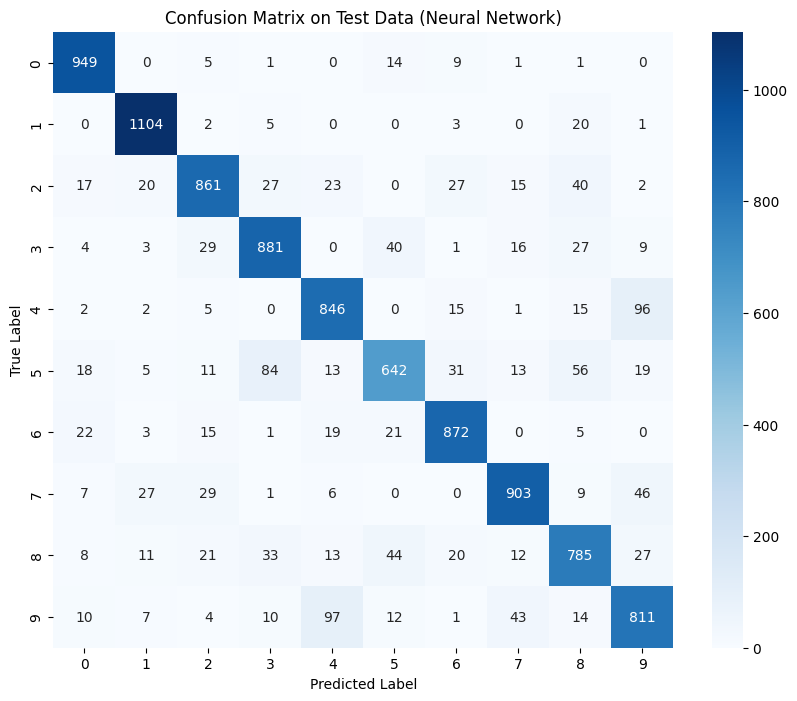

Confusion Matrix plot generated successfully.


In [25]:
# y_pred_test and y_true_test were already computed in the previous cell
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data (Neural Network)')
plt.show()

print("Confusion Matrix plot generated successfully.")

## 13. Conclusion & Assignment

In this notebook, we successfully implemented a **Neural Network with one hidden layer** from scratch, understanding its fundamental components: activation functions (ReLU and Softmax), multi-layer forward propagation, categorical cross-entropy loss, multi-layer backward propagation, and gradient descent for parameter updates. We applied it to the **MNIST multi-class classification** task, preprocess the data, trained the model, and evaluated its performance.

The model demonstrated strong performance on the test set, showcasing the effectiveness of a simpler neural network architecture for image classification. We also compared our implementation with Scikit-learn's `MLPClassifier`, observing similar performance, which validates our custom implementation and provides a benchmark for understanding more complex models.

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `parameters`, type: `dict`
value:
```
{'W1': <truncated for brevity>,
 'b1': <truncated for brevity>,
 'W2': <truncated for brevity>,
 'b2': <truncated for brevity>}
```
Variable #2
name: `cost_history`, type: `list`
value: `[<truncated for brevity>]`
Variable #3
name: `accuracy_history`, type: `list`
value: `[<truncated for brevity>]`
Variable #4
name: `y_pred_test`, type: `ndarray`
value: `array([<truncated for brevity>])`
Variable #5
name: `y_true_test`, type: `ndarray`
value: `array([<truncated for brevity>])`
Variable #6
name: `accuracy`, type: `float`
value: `<truncated for brevity>`
Variable #7
name: `cm`, type: `ndarray`
value:
```
array([[<truncated for brevity>]])
```

---

### Assignment

<img src="https://raw.githubusercontent.com/AshishJangra27/In-One-Go/refs/heads/main/resourcess/neural_network_with_mnist.png" alt="Artificial Neuron Banner" width="1000"/>

To further solidify your understanding and challenge yourself, try extending this implementation to include **three hidden layers** with the following neuron counts:

*   **Hidden Layer 1**: 512 neurons
*   **Hidden Layer 2**: 256 neurons
*   **Hidden Layer 3**: 64 neurons


Remember to adjust the parameter initialization, forward propagation, and backward propagation functions accordingly. This will give you practical experience with building deeper neural networks.